## Correlation and Linear Regression


#### we want to see how the iNaturalist observation is impacted by behavior / environmental factors. 

<b>Hypothesis</b> - The pattern of data collection is more influenced by the behavior of participants than by the population, environmental factors, such as green and blue space and other events. 

Data : 
<ul>
 <li>iNaturalist observations (2016-2023)</li>
 <li>poulation density Estimated population density per grid-cell. The dataset is available to download in Geotiff and ASCII XYZ format at a resolution of 30 arc (approximately 1km at the equator). The projection is Geographic Coordinate System, WGS84</li>
 <li>presence of green space/blue space downloaded using OSM tags</li>
</ul>

In [94]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
import seaborn as sns
import os
import numpy as np
from libpysal.weights import lag_spatial

# Getting the Data

In [14]:
path = '/Users/zahrafarook/Desktop/DataAnalysis/ExpectationSurface/'
dir_list = os.listdir(path)
print(dir_list)

['QGIS files', '.DS_Store', '`Expectation Surface-Copy1.ipynb', '`Expectation Surface _ SF.ipynb', 'Sri_Lanka', 'ES_with_PD', 'Bolivia', 'San_Francisco', '.ipynb_checkpoints', 'London']


In [15]:
#df = pd.read_csv("/Users/zahrafarook/Desktop/DataAnalysis/ExpectationSurface/ES_with_PD/Sri_Lanka/ES_gr_bl_colombo_final.csv")

In [177]:
df = gpd.read_file("/Users/zahrafarook/Desktop/DataAnalysis/ExpectationSurface/ES_with_PD/Sri_Lanka/colombo_model_final.gpkg")
df.head()

,id,left,top,right,bottom,row_index,col_index,area,X,Y,...,chi_square,blue_count,green_coun,has_green,has_blue,bl_ar_m2,gr_ar_m2,surface_gb,chi_clean,geometry
0,2.0,372739.6656,770369.7619,373739.6656,769369.7619,1.0,0.0,485290,79.852916,6.962084,...,-5.0,NaN,NaN,0,0,NaN,NaN,NoneNeg,-5,"MULTIPOLYGON (((373739.666 769696.326, 373739...."
1,3.0,372739.6656,769369.7619,373739.6656,768369.7619,2.0,0.0,983168,79.852916,6.953750,...,-5.0,NaN,NaN,0,0,NaN,NaN,NoneNeg,-5,"MULTIPOLYGON (((372758.105 769369.762, 373739...."
2,4.0,372739.6656,768369.7619,373739.6656,767369.7619,3.0,0.0,985594,79.852916,6.945417,...,-10.0,NaN,NaN,0,0,NaN,NaN,NoneNeg,-10,"MULTIPOLYGON (((372755.680 768369.762, 373739...."
3,5.0,372739.6656,767369.7619,373739.6656,766369.7619,4.0,0.0,988020,79.852916,6.937084,...,-6.0,2.0,3.0,1,1,462342.0,66754.0,GBNeg,-6,"MULTIPOLYGON (((372753.256 767369.762, 373739...."
4,6.0,372739.6656,766369.7619,373739.6656,765369.7619,5.0,0.0,990445,79.852916,6.928750,...,-3.0,2.0,5.0,1,1,553657.0,93948.0,GBNeg,-3,"MULTIPOLYGON (((372750.831 766369.762, 373739...."


In [16]:
df.head()

,id,left,top,right,bottom,row_index,col_index,area,X,Y,...,expected,actual,chi_square,blue_count,green_coun,has_green,has_blue,bl_ar_m2,gr_ar_m2,surface_gb
0,2,372739.6656,770369.7619,373739.6656,769369.7619,1,0,485290,79.852916,6.962084,...,25.0,0,-5.0,NaN,NaN,0,0,NaN,NaN,NoneNeg
1,3,372739.6656,769369.7619,373739.6656,768369.7619,2,0,983168,79.852916,6.953750,...,32.0,1,-5.0,NaN,NaN,0,0,NaN,NaN,NoneNeg
2,4,372739.6656,768369.7619,373739.6656,767369.7619,3,0,985594,79.852916,6.945417,...,103.0,5,-10.0,NaN,NaN,0,0,NaN,NaN,NoneNeg
3,5,372739.6656,767369.7619,373739.6656,766369.7619,4,0,988020,79.852916,6.937084,...,67.0,17,-6.0,2.0,3.0,1,1,462342.0,66754.0,GBNeg
4,6,372739.6656,766369.7619,373739.6656,765369.7619,5,0,990445,79.852916,6.928750,...,23.0,10,-3.0,2.0,5.0,1,1,553657.0,93948.0,GBNeg


In [179]:
df.rename(columns={'Z': 'population_density'}, inplace=True)

# Exploratory Data Analysis

In [178]:
df.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 762 entries, 0 to 761
Data columns (total 23 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   id          762 non-null    float64 
 1   left        762 non-null    float64 
 2   top         762 non-null    float64 
 3   right       762 non-null    float64 
 4   bottom      762 non-null    float64 
 5   row_index   762 non-null    float64 
 6   col_index   762 non-null    float64 
 7   area        762 non-null    int64   
 8   X           686 non-null    float64 
 9   Y           686 non-null    float64 
 10  Z           686 non-null    float64 
 11  expected    686 non-null    float64 
 12  actual      762 non-null    int64   
 13  chi_square  674 non-null    float64 
 14  blue_count  360 non-null    float64 
 15  green_coun  360 non-null    float64 
 16  has_green   762 non-null    int64   
 17  has_blue    762 non-null    int64   
 18  bl_ar_m2    360 non-null    float64 
 19  

In [180]:
df.describe()

,id,left,top,right,bottom,row_index,col_index,area,X,Y,...,expected,actual,chi_square,blue_count,green_coun,has_green,has_blue,bl_ar_m2,gr_ar_m2,chi_clean
count,762.000000,762.000000,762.000000,762.000000,762.000000,762.000000,762.000000,7.620000e+02,686.000000,686.000000,...,686.000000,762.000000,674.000000,360.000000,360.000000,762.000000,762.000000,3.600000e+02,3.600000e+02,762.000000
mean,567.035433,391214.731217,759586.297333,392214.731217,758586.297333,11.783465,18.475066,8.919319e+05,80.019680,6.869190,...,17.373178,15.649606,0.537092,1.950000,1.605556,0.262467,0.371391,1.659525e+06,3.599193e+04,0.475066
std,348.061061,11657.171759,6295.532869,11657.171759,6295.532869,6.295533,11.657172,2.612146e+05,0.104790,0.053182,...,19.570366,55.984434,15.829026,2.525138,3.146377,0.440264,0.483494,3.783054e+06,1.475069e+05,14.886695
min,2.000000,372739.665600,742369.761900,373739.665600,741369.761900,0.000000,0.000000,4.810000e+02,79.852916,6.728750,...,0.000000,0.000000,-12.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,-12.000000
25%,260.250000,380739.665600,754369.761900,381739.665600,753369.761900,7.000000,8.000000,1.000409e+06,79.927916,6.828750,...,4.000000,0.000000,-4.000000,1.000000,0.000000,0.000000,0.000000,9.592500e+02,0.000000e+00,-3.000000
50%,524.500000,389739.665600,759369.761900,390739.665600,758369.761900,12.000000,17.000000,1.000471e+06,80.002916,6.870417,...,12.000000,1.000000,-2.000000,1.000000,1.000000,0.000000,0.000000,6.140200e+04,1.539500e+03,-2.000000
75%,883.750000,401739.665600,764369.761900,402739.665600,763369.761900,17.000000,29.000000,1.000539e+06,80.111250,6.912084,...,23.000000,6.000000,-1.000000,2.000000,2.000000,1.000000,1.000000,7.310408e+05,1.325750e+04,0.000000
max,1234.000000,413739.665600,771369.761900,414739.665600,770369.761900,29.000000,41.000000,1.000614e+06,80.219583,6.970417,...,160.000000,944.000000,281.000000,20.000000,37.000000,1.000000,1.000000,1.337375e+07,1.115814e+06,281.000000


In [181]:
df.isnull().sum()

id                      0
left                    0
top                     0
right                   0
bottom                  0
row_index               0
col_index               0
area                    0
X                      76
Y                      76
population_density     76
expected               76
actual                  0
chi_square             88
blue_count            402
green_coun            402
has_green               0
has_blue                0
bl_ar_m2              402
gr_ar_m2              402
surface_gb              0
chi_clean               0
geometry                0
dtype: int64

In [182]:
#we are only remove the rows with NULL in Population density(Z)
df_clean = df.dropna(subset=['population_density']).copy()

In [183]:
df_clean.isnull().sum()

id                      0
left                    0
top                     0
right                   0
bottom                  0
row_index               0
col_index               0
area                    0
X                       0
Y                       0
population_density      0
expected                0
actual                  0
chi_square             12
blue_count            354
green_coun            354
has_green               0
has_blue                0
bl_ar_m2              354
gr_ar_m2              354
surface_gb              0
chi_clean               0
geometry                0
dtype: int64

In [184]:
print(f"Rows remaining after subset removal: {len(df_clean)}")


Rows remaining after subset removal: 686


### Check the Distribution 

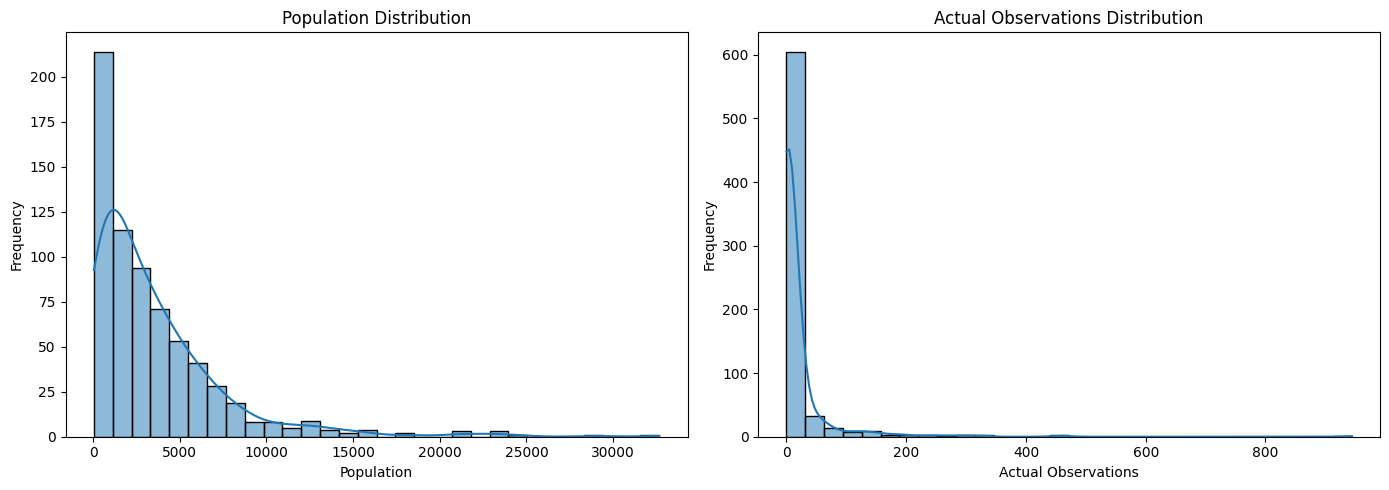

In [185]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram for 'population density'
sns.histplot(df_clean['population_density'], bins=30, ax=axes[0], kde=True)
axes[0].set_title('Population Distribution')
axes[0].set_xlabel('Population')
axes[0].set_ylabel('Frequency')

# Histogram for 'actual' (number of observations)
sns.histplot(df_clean['actual'], bins=30, ax=axes[1], kde=True)
axes[1].set_title('Actual Observations Distribution')
axes[1].set_xlabel('Actual Observations')
axes[1].set_ylabel('Frequency')



plt.tight_layout()
plt.show()

<p> Since the observation is skewed, we are doing the log transformation here.</p>

In [12]:
# log tranformation

In [186]:
df_clean = df_clean.copy()
df_clean['log_actual'] = np.log1p(df_clean['actual'])

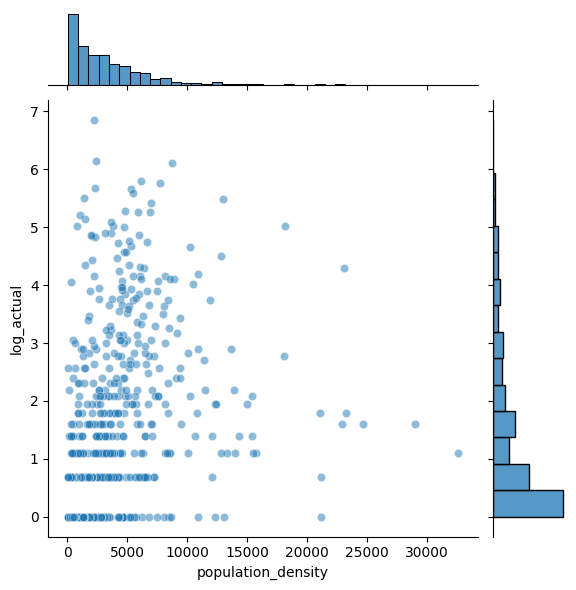

In [187]:
# observation vs population 
#sns.jointplot(x='actual', y='Z', data=df, alpha=0.5)
sns.jointplot(data=df_clean, x="population_density", y="log_actual",alpha=0.5)


In [32]:
#sns.pairplot(df, hue="actual")

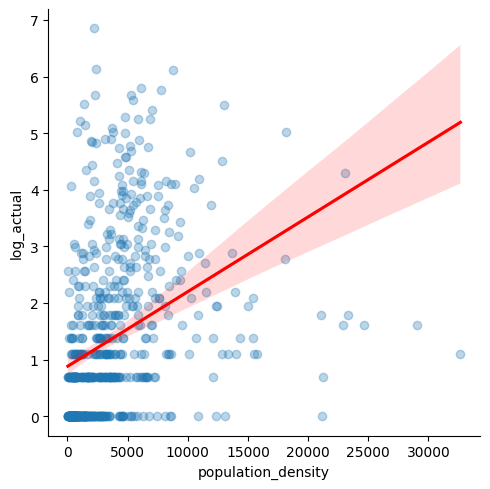

In [188]:
# 
sns.lmplot(x='population_density', 
           y='log_actual', 
           data=df_clean,
           scatter_kws={'alpha':0.3},line_kws={'color':'red'})

# Correlation Analysis

<p> Here we see the individual linear relationship between the dependent variable (observation , log transfered), and each of the independent variables (population density, green, blue space).</p>



In [95]:
from scipy.stats import pearsonr


### correlation , p value for observation and population density


In [96]:
def cor_coeffand_p_v(df):
    correlation, p_value = pearsonr(df['population_density'], df['log_actual'])
    print(f"Pearson Correlation: {correlation:.3f}, P-value: {p_value:.3f}")
    return correlation, p_value


In [97]:
correlation, p_val = cor_coeffand_p_v(df_clean)

Pearson Correlation: 0.353, P-value: 0.000


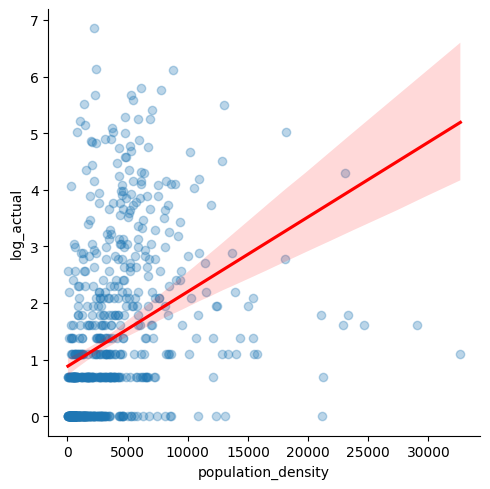

In [98]:
sns.lmplot(x='population_density', 
           y='log_actual', 
           data=df_clean,
           scatter_kws={'alpha':0.3},line_kws={'color':'red'})

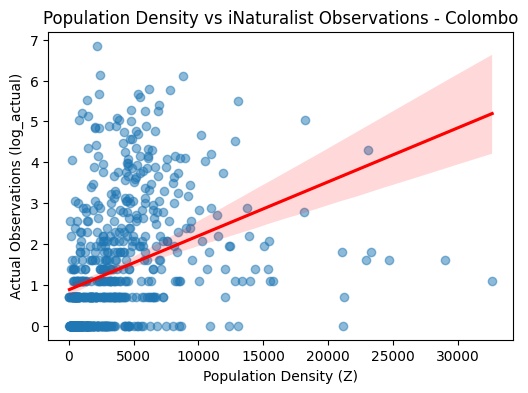

In [99]:
plt.figure(figsize=(6, 4))
sns.regplot(x='population_density', y='log_actual', data=df_clean, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

plt.xlabel('Population Density (Z)')
plt.ylabel('Actual Observations (log_actual)')
plt.title('Population Density vs iNaturalist Observations - Colombo')

plt.show()


### correlation , p value for observation and green and blue space


In [100]:
r_green, p_green = pearsonr(df_clean['has_green'], df_clean['log_actual'])
r_blue, p_blue = pearsonr(df_clean['has_blue'], df_clean['log_actual'])
print ('Pearson Correlation and P-value of :')
print(f"Greenspace  : r={r_green:.3f}, p={p_green:.3f}")
print(f"Blue space : r={r_blue:.3f}, p={p_blue:.3f}")

Pearson Correlation and P-value of :
Greenspace  : r=0.436, p=0.000
Blue space : r=0.244, p=0.000


def cor_coeffand_p_v_gr(df):
    """
    Calculates the Pearson correlation and P-value between 'gr_area_m2' 
    and 'log_actual' after removing rows with null values in either column.
    """
    temp_df = df_clean.dropna(subset=['has_green', 'log_actual']).copy()
    # Calculate correlation on the cleaned data
    correlation, p_value = pearsonr(temp_df['has_green'], temp_df['log_actual'])
    print(f"Pearson Correlation: {correlation:.3f}, P-value: {p_value:.3f}")
    return correlation, p_value
   
 correlation, p_val = cor_coeffand_p_v_gr(df_clean)

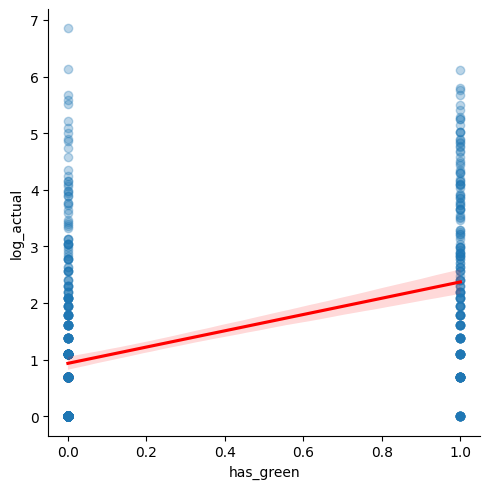

In [23]:
sns.lmplot(x='has_green', 
           y='log_actual', 
           data=df_clean,
           scatter_kws={'alpha':0.3},line_kws={'color':'red'})

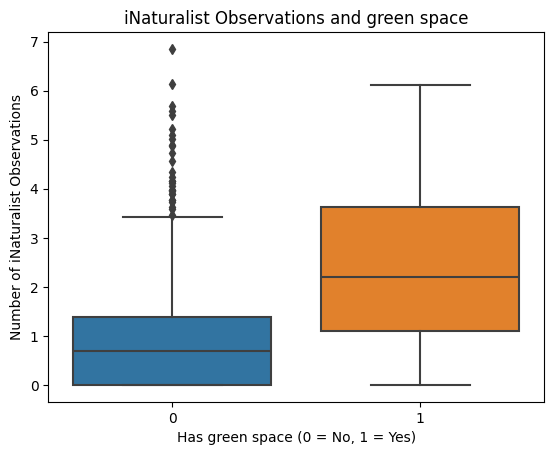

In [48]:
sns.boxplot(x='has_green', y='log_actual', data=df_clean)
plt.xlabel('Has green space (0 = No, 1 = Yes)')
plt.ylabel('Number of iNaturalist Observations')
plt.title('iNaturalist Observations and green space')
plt.show()

## Splitting the data
X are the predictores, and y is the output. The model  will take in the values in the X variable and predict y with a linear regression algorithm using scikit l.
We will use the SciKit Learn library to create the model.

In [54]:
from sklearn.model_selection import train_test_split


In [26]:
 df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 686 entries, 0 to 760
Data columns (total 22 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          686 non-null    int64  
 1   left        686 non-null    float64
 2   top         686 non-null    float64
 3   right       686 non-null    float64
 4   bottom      686 non-null    float64
 5   row_index   686 non-null    int64  
 6   col_index   686 non-null    int64  
 7   area        686 non-null    int64  
 8   X           686 non-null    float64
 9   Y           686 non-null    float64
 10  Z           686 non-null    float64
 11  expected    686 non-null    float64
 12  actual      686 non-null    int64  
 13  chi_square  674 non-null    float64
 14  blue_count  332 non-null    float64
 15  green_coun  332 non-null    float64
 16  has_green   686 non-null    int64  
 17  has_blue    686 non-null    int64  
 18  bl_ar_m2    332 non-null    float64
 19  gr_ar_m2    332 non-null    f

###  Does a larger population lead to more observations?

In [191]:
X =  df_clean[['population_density']] #Independent Variable (X)
y =  df_clean['log_actual'] #dependent Variable (y) here we check with one variable (population_density)

In [192]:
X.head()
y.head()

0    0.000000
1    0.693147
2    1.791759
3    2.890372
4    2.397895
Name: log_actual, dtype: float64

<p> split the data into two parts. 70:30 </p>

In [193]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state=42)

## Training the Model with single variable and mulivariable regression

In this section, we create the model and feed the training data to it. <br> This model will tell us which input has the biggest impact in the output (observation)</br>.

### Signle Variable (Population vs Observation)

In [56]:
from sklearn.linear_model import LinearRegression

In [57]:
lm = LinearRegression()

In [58]:
lm.fit(X_train,y_train)

LinearRegression()

In [59]:
lm.coef_

array([0.00013344])

In [60]:
# the coefficients
lm.coef_

array([0.00013344])

In [61]:
# r squared
lm.score(X, y)

0.12417095522530042

In [62]:
# The coefficients in a dataframe
cdf = pd.DataFrame(lm.coef_,X.columns,columns=['Coef'])
print(cdf)

                        Coef
population_density  0.000133


## Training the model with regression using OLS


### Single variable - population density

In [194]:
import statsmodels.api as sm

In [195]:
X = sm.add_constant(X_train)
model = sm.OLS(y_train, X)
model_fit = model.fit()
print(model_fit.summary())

                            OLS Regression Results                            
Dep. Variable:             log_actual   R-squared:                       0.112
Model:                            OLS   Adj. R-squared:                  0.110
Method:                 Least Squares   F-statistic:                     60.10
Date:                Sun, 12 Oct 2025   Prob (F-statistic):           5.48e-14
Time:                        23:52:03   Log-Likelihood:                -846.33
No. Observations:                 480   AIC:                             1697.
Df Residuals:                     478   BIC:                             1705.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.8968      0

## Predicting Test Data
Now that the model is trained, 
we should be able to use it to make our predictions and evaluate our model. 
The scatter plot below plots the actual y values to the model's predictions. 

In [196]:
X_test_const = sm.add_constant(X_test, prepend=True)
predictions = model_fit.predict(X_test_const)
predictions

317    1.272928
719    1.024179
287    1.323131
372    1.248032
352    1.164153
         ...   
234    1.314187
663    0.971461
78     2.610206
16     3.001271
745    1.461885
Length: 206, dtype: float64

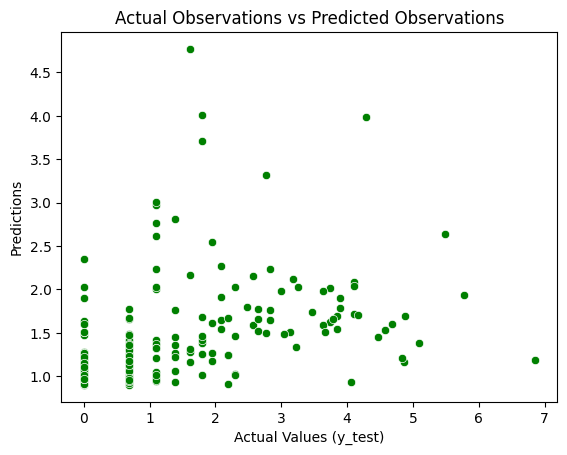

In [197]:
sns.scatterplot(x=y_test, y=predictions,color = 'green') 
plt.xlabel('Actual Values (y_test)') # Added x-label for clarity
plt.ylabel('Predictions')
plt.title('Actual Observations vs Predicted Observations') 
plt.show() # Added show() to display the plot

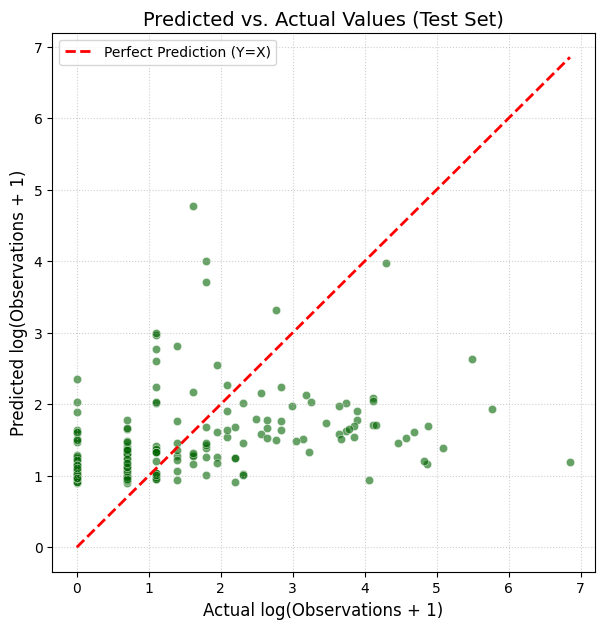

In [198]:
plt.figure(figsize=(7, 7))
sns.scatterplot(x=y_test, y=predictions, color='darkgreen', alpha=0.6)

# Add  45-degree reference line (Y = X)
min_val = min(y_test.min(), predictions.min())
max_val = max(y_test.max(), predictions.max())

# Plot the line from the min to max values
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction (Y=X)')

plt.title('Predicted vs. Actual Values (Test Set)', fontsize=14)
plt.xlabel('Actual log(Observations + 1)', fontsize=12)
plt.ylabel('Predicted log(Observations + 1)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

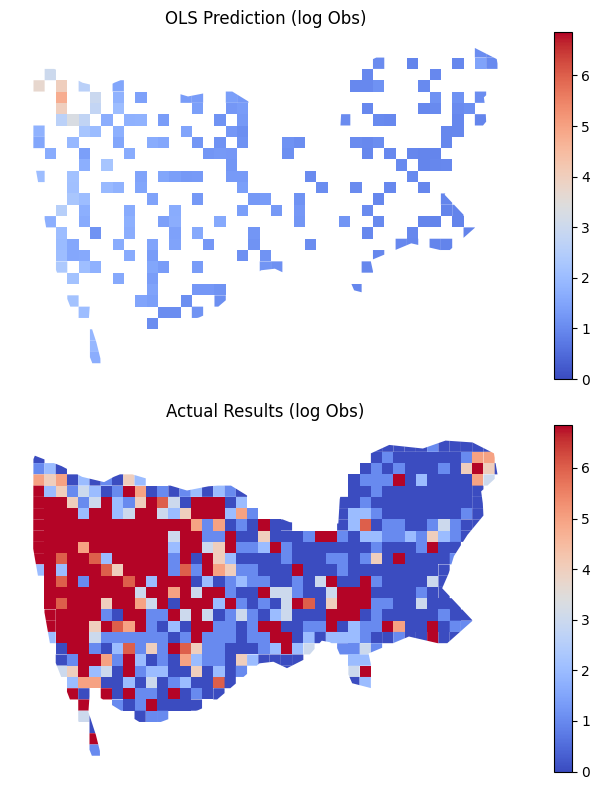

In [210]:
import matplotlib.pyplot as plt
df_clean['predicted'] = predictions 

f, axs = plt.subplots(2, 1, figsize=(7, 8))

# Get the max value across both columns to ensure a consistent color scale
# We'll use the maximum value found in both the 'actual' and 'predicted' columns 
# to ensure the color bar is comparable.
vmax_val = df_clean[['predicted', 'log_actual']].max().max()

df_clean.plot(column="predicted", legend=True, cmap="coolwarm", vmin=0, vmax=vmax_val,ax=axs[0],edgecolor='none')
axs[0].set_title("OLS Prediction (log Obs)")
axs[0].set_axis_off()

# Plot 2: Actual
# Use the existing column name "actual"
df_clean.plot(
    column="actual", legend=True, cmap="coolwarm", vmin=0, vmax=vmax_val,ax=axs[1],edgecolor='none')

axs[1].set_title("Actual Results (log Obs)")
axs[1].set_axis_off()

plt.tight_layout()
plt.show()

## Evaluation of the model

In [67]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

In [68]:
print('Mean Absolute Error:',mean_absolute_error(y_test, predictions))
print('Mean Squared Error:',mean_squared_error(y_test, predictions))
print('Root Mean Squared Error:',math.sqrt(mean_squared_error(y_test, predictions)))

Mean Absolute Error: 1.08214352079783
Mean Squared Error: 1.8629374120482305
Root Mean Squared Error: 1.3648946523626762


## Residuals
### Distribution plot of the residuals of the model's predictions. They should be normally distributed.

In [69]:
import pylab 
import scipy.stats as stats

In [117]:
residuals = y_test-predictions


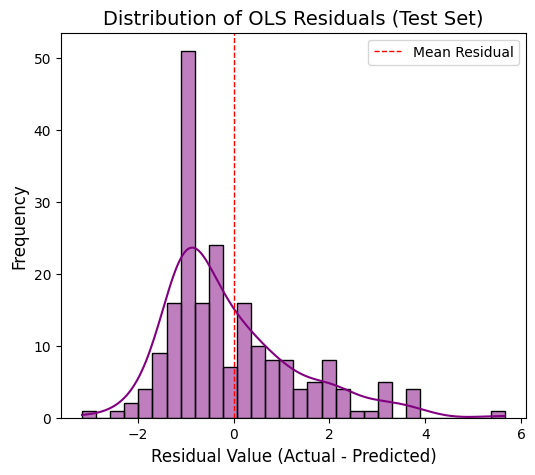

In [119]:
plt.figure(figsize=(6, 5))
sns.histplot(residuals, bins=30, kde=True, color='purple')
plt.title('Distribution of OLS Residuals (Test Set)', fontsize=14)
plt.xlabel('Residual Value (Actual - Predicted)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(0, color='red', linestyle='--', linewidth=1, label='Mean Residual')#(Should be near 0)
plt.legend()
plt.show()

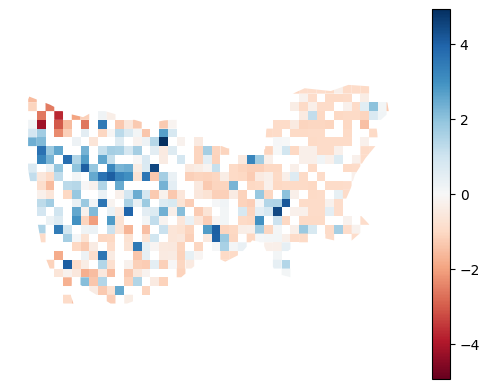

In [215]:
df_clean["residual"] = model_fit.resid
max_residual = model_fit.resid.abs().max()
ax = df_clean.plot(
    "residual", legend=True, cmap="RdBu", vmin=-max_residual, vmax=max_residual
)
ax.set_axis_off()

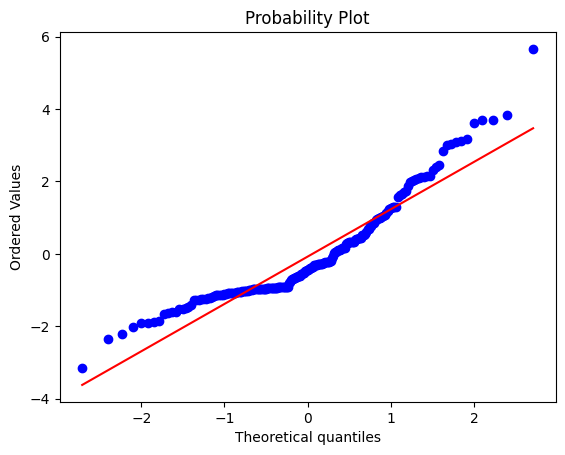

In [120]:
stats.probplot(residuals, dist="norm", plot=pylab)
pylab.show()

# Training the model with multivariable regression using OLS

In [131]:
X1 =  df_clean[['population_density','has_green','has_blue']] #Independent Variable (X)
y1 =  df_clean['log_actual'] #ddependent Variable (y)

In [132]:
X1_train, X1_test, y1_train, y1_test = train_test_split(X1,y1,test_size=0.3, random_state=42)

In [133]:
lm1 = LinearRegression()

In [134]:
lm1.fit(X1_train,y1_train)

LinearRegression()

In [135]:
# the coefficients
lm1.coef_

array([6.86623142e-05, 9.16795462e-01, 3.48087329e-01])

In [136]:
# r squared
lm1.score(X1, y1)

0.22538410925494168

In [139]:
# The coefficients in a dataframe
#cdf1 = pd.DataFrame(lm1.coef_,X.columns,columns=['Coef'])
#print(cdf1)

In [140]:
X1 = sm.add_constant(X1_train)
model = sm.OLS(y1_train, X1)
model_fit = model.fit()
print(model_fit.summary())

                            OLS Regression Results                            
Dep. Variable:             log_actual   R-squared:                       0.194
Model:                            OLS   Adj. R-squared:                  0.188
Method:                 Least Squares   F-statistic:                     38.08
Date:                Sun, 12 Oct 2025   Prob (F-statistic):           4.52e-22
Time:                        22:50:00   Log-Likelihood:                -823.13
No. Observations:                 480   AIC:                             1654.
Df Residuals:                     476   BIC:                             1671.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.7255      0

## Predicting Test Data
Now that the model is trained, 
we should be able to use it to make our predictions and evaluate our model. 
The scatter plot below plots the actual y values to the model's predictions. 

## Multivariable 

In [143]:
X1_test_const = sm.add_constant(X1_test, prepend=True)
predictions1 = model_fit.predict(X1_test_const)
predictions1

317    1.835824
719    0.791032
287    1.292949
372    1.254306
352    1.211144
         ...   
234    0.940259
663    0.763905
78     1.955230
16     1.808370
745    1.933054
Length: 206, dtype: float64

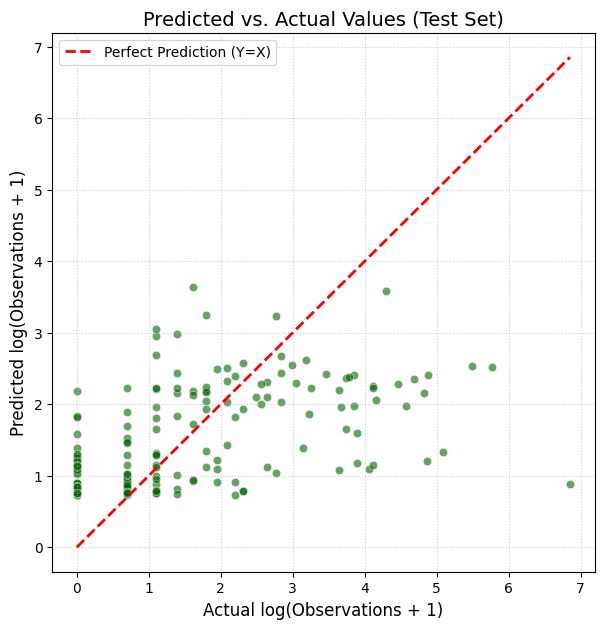

In [151]:
plt.figure(figsize=(7, 7))
sns.scatterplot(x=y1_test, y=predictions1, color='darkgreen', alpha=0.6)

# Add  45-degree reference line (Y = X)
min_val = min(y1_test.min(), predictions1.min())
max_val = max(y1_test.max(), predictions1.max())

# Plot the line from the min to max values
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction (Y=X)')

plt.title('Predicted vs. Actual Values (Test Set)', fontsize=14)
plt.xlabel('Actual log(Observations + 1)', fontsize=12)
plt.ylabel('Predicted log(Observations + 1)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

## Evaluation of the model

In [152]:
print('Mean Absolute Error:',mean_absolute_error(y1_test, predictions1))
print('Mean Squared Error:',mean_squared_error(y1_test, predictions1))
print('Root Mean Squared Error:',math.sqrt(mean_squared_error(y1_test, predictions1)))

Mean Absolute Error: 0.9491612202056114
Mean Squared Error: 1.5390242872548774
Root Mean Squared Error: 1.2405741764420528



# Residuals
### Distribution plot of the residuals of the model's predictions. They should be normally distributed.

In [156]:
residuals1 = y1_test-predictions1


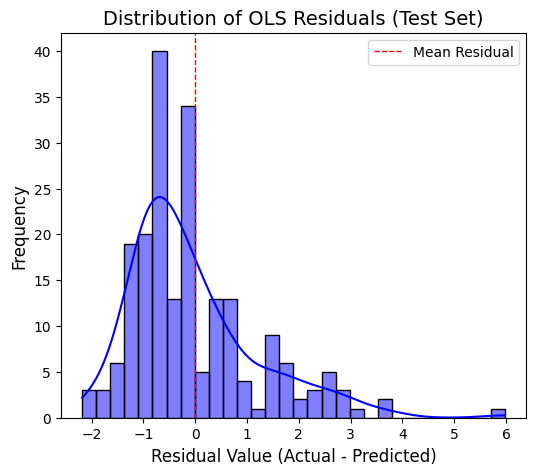

In [155]:
plt.figure(figsize=(6, 5))
sns.histplot(residuals1, bins=30, kde=True, color='blue')
plt.title('Distribution of OLS Residuals (Test Set)', fontsize=14)
plt.xlabel('Residual Value (Actual - Predicted)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(0, color='red', linestyle='--', linewidth=1, label='Mean Residual')#(Should be near 0)
plt.legend()
plt.show()

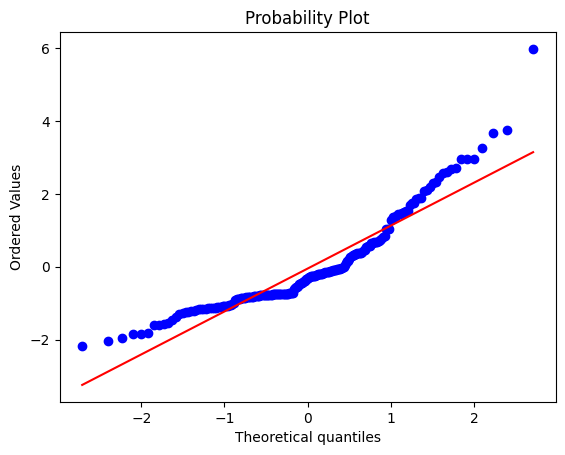

In [157]:
stats.probplot(residuals1, dist="norm", plot=pylab)
pylab.show()

# OLS and Moran 1 Spatial AutoCorrelation on entire dataset

(measure of similarity between neighboring areal units, or spatial autocorrelation. )

<p> Her we are trying to test the OLS assumption of independent errors on the full dataset. The result of Moran I results will determine whether we can use the OLS model or use the spatial regression model.</p>


In [249]:
import libpysal.weights as lpw  
from esda.moran import Moran   
import libpysal.weights as lpw
from esda.moran import Moran 
import geopandas as gpd
import statsmodels.api as sm

In [250]:
gdf = gpd.read_file('ES_GR_BL_Final.shp')

In [251]:
X_train_full = df_clean[['population_density','has_green','has_blue']]
Y_train_full = df_clean['log_actual'] 

In [252]:
X_train_full.shape

(686, 3)

In [253]:
X_all = sm.add_constant(X_train_full)
model_all = sm.OLS(Y_train_full, X_all)
model_fit_all = model_all.fit()
print(model_fit_all.summary())

                            OLS Regression Results                            
Dep. Variable:             log_actual   R-squared:                       0.228
Model:                            OLS   Adj. R-squared:                  0.224
Method:                 Least Squares   F-statistic:                     67.03
Date:                Mon, 13 Oct 2025   Prob (F-statistic):           5.42e-38
Time:                        11:03:49   Log-Likelihood:                -1159.7
No. Observations:                 686   AIC:                             2327.
Df Residuals:                     682   BIC:                             2346.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.6962      0

In [266]:
predictions_all = model_fit_all.predict()
predictions_all

array([1.03752437, 1.14042516, 2.12004048, 2.97315575, 2.35889473,
       2.73694821, 2.22185272, 1.00121722, 2.08160309, 1.43894352,
       1.2691372 , 1.7620207 , 3.44383682, 4.25374221, 3.27644091,
       2.60012916, 2.18390135, 1.91645151, 2.15508522, 2.98549691,
       2.01078145, 2.82487241, 1.32977082, 2.53667592, 2.18841155,
       2.31870096, 1.27542546, 2.88218275, 3.35158962, 3.73778342,
       3.60785858, 2.65675099, 2.29064923, 2.2812715 , 2.65820121,
       3.0628028 , 2.94693926, 2.61177079, 2.75727856, 2.61409691,
       2.5500671 , 2.34776455, 2.32407542, 1.27138209, 1.70129654,
       1.78259973, 3.47620435, 3.21015373, 3.59460508, 3.27068386,
       2.47793688, 2.56032589, 2.91464459, 2.85165812, 2.66764259,
       2.3803933 , 1.3903556 , 1.42723448, 2.56636662, 2.24214057,
       2.09725845, 2.10461575, 1.5128513 , 1.60941899, 1.39473539,
       2.4115783 , 1.83436191, 3.08700268, 2.53618738, 2.9935352 ,
       2.72530081, 2.3724085 , 2.29575682, 2.4510438 , 2.17477

In [268]:
#another way to predict 
predictions_all = model_fit_all.fittedvalues
predictions_all

0      1.037524
1      1.140425
2      2.120040
3      2.973156
4      2.358895
         ...   
754    0.733711
755    2.106208
756    1.262606
757    2.210998
760    0.887721
Length: 686, dtype: float64

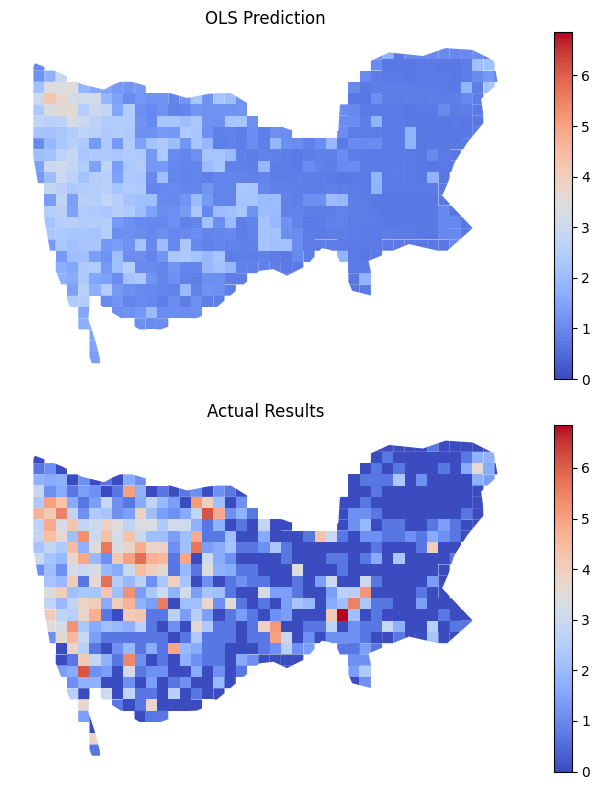

In [289]:
# Add Predictions and Actuals to GeoDataFrame 

df_clean['predicted'] = predictions_all
df_clean['actual'] = Y_train_full # Y_full is the log_observations 

# plot
f, axs = plt.subplots(2, 1, figsize=(7, 8))

# Find the max value across both columns for consistent color scale
vmax_val = df_clean[['predicted', 'actual']].max().max()

# Plot 1: Prediction
df_clean.plot(
    column="predicted", 
    legend=True, 
    cmap="coolwarm", 
    vmin=0, 
    vmax=vmax_val,  
    ax=axs[0],
    edgecolor='none'
)
axs[0].set_title("OLS Prediction")
axs[0].set_axis_off()

# Plot 2: Actual
df_clean.plot(
    column="actual", 
    legend=True, 
    cmap="coolwarm", 
    vmin=0, 
    vmax=vmax_val, 
    ax=axs[1],
    edgecolor='none'
)
axs[1].set_title("Actual Results")
axs[1].set_axis_off()

plt.tight_layout()
plt.show()

remove this
residuals_all = Y_train_full - predictions_all
residuals_all

In [297]:
# This is better
residuals_all = model_fit_all.resid 
residuals_all

0     -1.037524
1     -0.447278
2     -0.328281
3     -0.082784
4      0.039001
         ...   
754   -0.733711
755   -0.314449
756    0.346832
757   -0.824704
760   -0.887721
Length: 686, dtype: float64

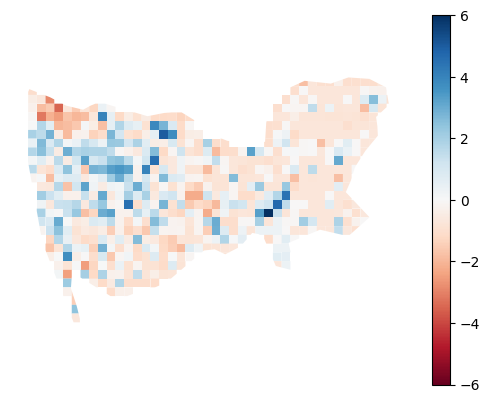

In [298]:
#df_clean["residuals_all"] = model_fit_all.resid
max_residual = model_fit_all.resid.abs().max()
ax = df_clean.plot(
    "residuals_all", legend=True, cmap="RdBu", vmin=-max_residual, vmax=max_residual
)
ax.set_axis_off()

All of the observations in blue (residual above 0) have reported
higher obs than the model assumes based on population,green/blue space, while all in red reported lower obs than what is expected.
However, we need to analyse the spatial structure of residuals . One way to diagnose is using spatial autocorrelation and understand the spatial clusters of residuals.

#  Spatial Diagnostic Check (Moran's I)
# Moran 1 Spatial AutoCorrelation

https://martinfleischmann.net/sds/autocorrelation/hands_on.html </br>
https://martinfleischmann.net/sds/regression/hands_on.html#geographically-weighted-regression 

In [302]:
#First, create a contiguity graph and row-normalise it.
contiguity_r = graph.Graph.build_contiguity(df_clean).transform("r")

Then you can generate a Moran plot of residuals. For that, you will need
the lag of residuals.

In [303]:
df_clean["residual_lag"] = contiguity_r.lag(df_clean["residual"])

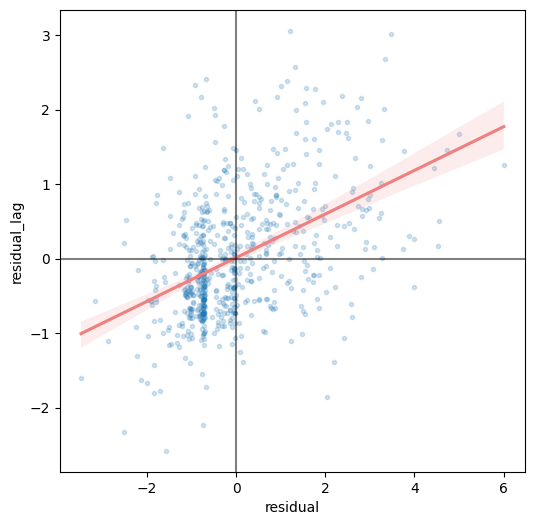

In [304]:
f, ax = plt.subplots(1, figsize=(6, 6))
sns.regplot(
    x="residual",
    y="residual_lag",
    data=df_clean,
    marker=".",
    scatter_kws={"alpha": 0.2},
    line_kws=dict(color="lightcoral")
)
plt.axvline(0, c="black", alpha=0.5)
plt.axhline(0, c="black", alpha=0.5);

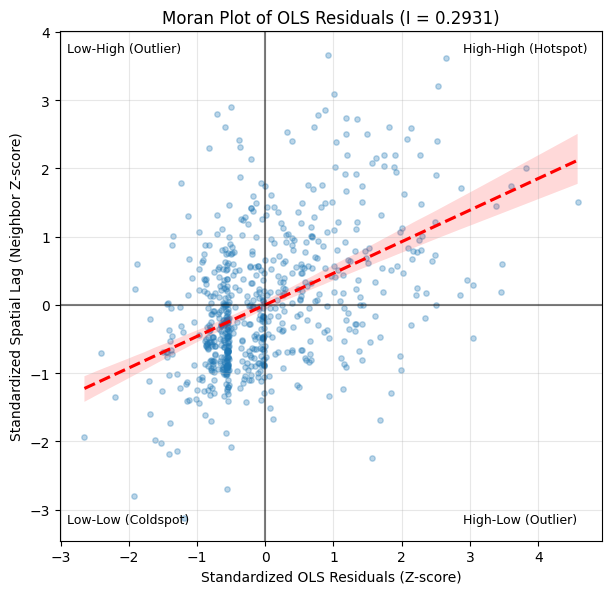

In [342]:

residuals = df_clean['residual'].values 

# Calculate Spatial Lag 
# This gives the weighted average residual of each cell's neighbors (W * epsilon)
lag_residuals = lag_spatial(contiguity_r, residuals)

# Standardization 
# Convert both the residuals and the lag to Z-scores (Mean=0, StdDev=1)
z_residuals = (residuals - residuals.mean()) / residuals.std()
z_lag_residuals = (lag_residuals - lag_residuals.mean()) / lag_residuals.std()

# plot
f, ax = plt.subplots(1, figsize=(7, 7))

sns.regplot(
    x=z_residuals, 
    y=z_lag_residuals,
    marker="o",
    scatter_kws={"alpha": 0.3, "s": 15}, # Smaller, semi-transparent points
    line_kws=dict(color="red", linestyle="--"),
    ax=ax
)

ax.set_aspect('equal')
ax.set_xlabel("Standardized OLS Residuals (Z-score)")
ax.set_ylabel("Standardized Spatial Lag (Neighbor Z-score)")
ax.set_title(f"Moran Plot of OLS Residuals (I = {global_moran.I:.4f})")

# Add the center lines at Z=0
plt.axvline(0, c="black", alpha=0.5)
plt.axhline(0, c="black", alpha=0.5)

plt.text(2.9, 3.7, "High-High (Hotspot)", fontsize=9)
plt.text(2.9, -3.2, "High-Low (Outlier)", fontsize=9)
plt.text(-2.9, 3.7, "Low-High (Outlier)", fontsize=9)
plt.text(-2.9, -3.2, "Low-Low (Coldspot)", fontsize=9)

plt.grid(True, alpha=0.3)
plt.show()

In [312]:
global_moran = esda.Moran(df_clean['residual'], contiguity_r) 

# Print the key statistical results
print("--- Global Moran's I Test Results ---")
print(f"Moran's I Statistic (I): {global_moran.I:.4f}")
print(f"P-value (P_sim): {global_moran.p_sim:.4f}")
print(f"Z-Score (Z_sim): {global_moran.z_sim:.4f}")
print("-------------------------------------")

#check the key hypothesis (P-value)
if moran.p_sim <= 0.05:
    print("\nCONCLUSION: OLS Assumption of Independent Errors IS VIOLATED.")
    print("ACTION: Must use a Spatial Regression Model.")
else:
    print("\nCONCLUSION: OLS Assumption of Independent Errors is MET.")
    print("ACTION: Standard OLS results are valid.")

--- Global Moran's I Test Results ---
Moran's I Statistic (I): 0.2931
P-value (P_sim): 0.0010
Z-Score (Z_sim): 10.6228
-------------------------------------

CONCLUSION: OLS Assumption of Independent Errors IS VIOLATED.
ACTION: Must use a Spatial Regression Model.


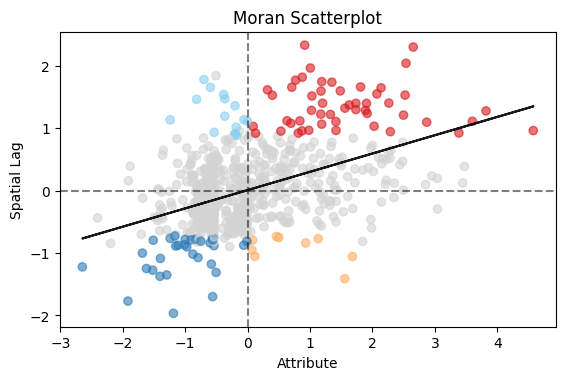

In [343]:
_ = lisa.plot_scatter()

In [305]:
lisa = esda.Moran_Local(df_clean['residual'], contiguity_r)

In [310]:
lisa.explore(df_clean, prefer_canvas=True, tiles="CartoDB Positron")

The outcome of LISA shows small clusters of both overpredicted
(High-High) and underpredicted (Low-Low) areas. The overpredicted are
mostly in colombo in areas, where wetlands are. 

# Spatially lagged Model

In [344]:
import pandas as pd
import numpy as np
from libpysal.weights import contiguity 
from spreg import ML_Lag as SpatialLagModel #

Y = df_clean['log_actual'].values.reshape((-1, 1))
X = df_clean[['population_density', 'has_green', 'has_blue']].values

# Add a constant term to the X matrix
X = np.hstack([np.ones(Y.shape), X])

# W - row-standardized Queen Contiguity matrix
W = contiguity_r

In [347]:
slm_model = SpatialLagModel(
    Y,          # obs
    X,          # (Pop, Green, Blue, Constant)
    w=W,        # Spatial Weights Matrix (W)
    name_y='log_observations',
    name_x=['CONSTANT', 'pop_density', 'green_space', 'blue_space'],
    name_w='Queen_R',
    name_ds='Colombo_iNat_Grid'
)

# Print the model summary
print("- Spatial Lag Model (SLM) Results -")
print(slm_model.summary)

--- Spatial Lag Model (SLM) Results ---
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG (METHOD = FULL)
-----------------------------------------------------------------
Data set            :Colombo_iNat_Grid
Weights matrix      :     Queen_R
Dependent Variable  :log_observations                Number of Observations:         686
Mean dependent var  :      1.3467                Number of Variables   :           5
S.D. dependent var  :      1.4941                Degrees of Freedom    :         681
Pseudo R-squared    :      0.4154
Spatial Pseudo R-squared:  0.2746
Log likelihood      :  -1092.7039
Sigma-square ML     :      1.3181                Akaike info criterion :    2195.408
S.E of regression   :      1.1481                Schwarz criterion     :    2218.062

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
--------------

In [349]:
#_ = df_clean.plot("has_blue", cmap="GnBu", linewidth=.1, edgecolor="grey")


In [348]:
#_ = df_clean.plot("has_green", cmap="BuGn", linewidth=.1, edgecolor="grey")
